In [1]:
import os
import re
import glob
import pickle 
import numpy as np
import netCDF4 as nc
import h5py

import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

In [2]:
color_maps_rgb = {"background": np.array([147,112,219]), #purple
             "shadow_mask": np.array([0, 128, 0]), #geen
             "cloud_mask": np.array([255,255,0])}  #yellow

mask_types = {"background": 0,
               "shadow_mask": 1, 
               "cloud_mask": 2,
             }

In [3]:
base_path_l1 = "/Volumes/EXTERNO-MP/TEMPO_l1"
l1_files = glob.glob(f"{base_path_l1}/*.nc")
base_path_l2 = "../data/raw_l2_v3"
out_path = "../data/TEMPO_cs_RGB_all"
band = "band_290_490_nm"
version = "V03"

cloud_threshold = 0.3
shadow_threshold = 0.05

In [4]:
banned_objs = [
"TEMPO_RAD_L1_V04_20250909T190538Z_S010G01-001",
"TEMPO_RAD_L1_V04_20250909T221218Z_S013G02-018",
"TEMPO_RAD_L1_V04_20250909T234546Z_S015G01-030",
"TEMPO_RAD_L1_V04_20250909T121157Z_S002G05-092",
"TEMPO_RAD_L1_V04_20250909T220538Z_S013G01-015",
"TEMPO_RAD_L1_V04_20250909T195538Z_S011G01-058",
"TEMPO_RAD_L1_V04_20250909T191846Z_S010G03-005",
"TEMPO_RAD_L1_V04_20250909T200846Z_S011G03-054",
"TEMPO_RAD_L1_V04_20250909T191212Z_S010G02-006",
"TEMPO_RAD_L1_V04_20250909T210538Z_S012G01-008",
"TEMPO_RAD_L1_V04_20250909T125842Z_S003G06-094",
"TEMPO_RAD_L1_V04_20250909T235906Z_S015G03-003",
"TEMPO_RAD_L1_V04_20250909T230538Z_S014G01-028",
"TEMPO_RAD_L1_V04_20250909T135205Z_S004G08-100",
"TEMPO_RAD_L1_V04_20250909T200212Z_S011G02-056",
"TEMPO_RAD_L1_V04_20250909T135842Z_S004G09-099",
"TEMPO_RAD_L1_V04_20250909T121834Z_S002G06-091",
"TEMPO_RAD_L1_V04_20250909T235226Z_S015G02-004",
"TEMPO_RAD_L1_V04_20250909T134528Z_S004G07-060",
]
print(len(l1_files))
l1_files = [file for file in l1_files if file.split("/")[-1].split(".")[0] not in banned_objs]
print(len(l1_files))

98
79


In [5]:
def extract_timestamp_scan(filename):
    """Extract timestamp and scan/granule info from filename"""
    # Pattern: TEMPO_{PRODUCT}_L{LEVEL}_V04_{TIMESTAMP}_S{SCAN}G{GRANULE}
    match = re.search(r'(\d{8}T\d{6}Z)_S(\d{3})G(\d{2})', filename)
    if match:
        return match.group(1), match.group(2), match.group(3)
    return None, None, None

def find_matching_l2_file(l1_file, l2_dir='L2', version="V03"):
    """Find corresponding L2 cloud file for an L1 file"""
    timestamp, scan, granule = extract_timestamp_scan(l1_file)
    print(l1_file, timestamp, scan, granule)
    if not timestamp:
        return None
    
    # L2 cloud files have format: TEMPO_CLDO4_L2_V04_{TIMESTAMP}_S{SCAN}G{GRANULE}.nc
    # Note: L2 files might not have the -034 suffix that L1 has
    pattern = f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G{granule.split('-')[0]}.nc"
    l2_path = os.path.join(l2_dir, pattern)
    
    if os.path.exists(l2_path):
        return l2_path
    
    # Try with wildcard if exact match not found
    search_pattern = os.path.join(l2_dir, f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G*.nc")
    matches = glob.glob(search_pattern)
    return matches[0] if matches else None

In [6]:
def compute_potential_shadow_mask(l2_file, band='band_290_490_nm', 
                                   cloud_threshold=0.05):
    """
    Compute potential cloud shadow mask using L2 cloud fraction and geolocation data
    
    Parameters:
    -----------
    nc_file : str
        Path to L1B NetCDF file
    l2_file : str  
        Path to L2 file (HDF5 or NetCDF)
    band : str
        Band name for L1B data
    cloud_threshold : float
        Cloud fraction threshold (default 0.05 as in DARCLOS)
    """        
    with nc.Dataset(l2_file) as f:
        lat = f['geolocation']['latitude'][:]
        lat = lat.filled(fill_value=np.nan)
        
        lon = f['geolocation']['longitude'][:]
        lon = lon.filled(fill_value=np.nan)
        
        solar_zenith = f['geolocation']['solar_zenith_angle'][:]
        solar_zenith = solar_zenith.filled(fill_value=np.nan)
        solar_azimuth = f['geolocation']['solar_azimuth_angle'][:]
        solar_azimuth = solar_azimuth.filled(fill_value=np.nan)
        viewing_zenith = f['geolocation']['viewing_zenith_angle'][:]
        viewing_zenith = viewing_zenith.filled(fill_value=np.nan)
        viewing_azimuth = f['geolocation']['viewing_azimuth_angle'][:]
        viewing_azimuth = viewing_azimuth.filled(fill_value=np.nan)
    
        cloud_fraction = f['product']['cloud_fraction'][:]
        cloud_fraction = cloud_fraction.filled(fill_value=-999)
        
        terrain_height = f['support_data']['terrain_height'][:]
        terrain_height = terrain_height.filled(fill_value=0)

        p = f['product']['cloud_pressure'][:]
        p = p.filled(fill_value=0.1)
        
        psfc = f['support_data']['surface_pressure'][:]

    # Safety margin for cloud height (50% as in DARCLOS)
    C = 0.5
    Hscale = 8000

    print(f"  Cloud fraction range: {np.nanmin(cloud_fraction):.3f} to {np.nanmax(cloud_fraction):.3f}")
    
    # Create cloud mask using threshold (as in DARCLOS)
    cloud_mask = cloud_fraction >= cloud_threshold
    
    # Initialize shadow mask
    shadow_mask = np.zeros_like(cloud_mask, dtype=bool)
    #z = np.zeros_like(cloud_mask, dtype=float)
    
    # For each cloud pixel, compute potential shadow location
    cloud_pixels = cloud_mask
    rows, cols = np.where(cloud_pixels)
    print(f"  Processing {len(rows)} cloud pixels...")
    
    for idx, (i, j) in enumerate(zip(rows, cols)):
        if idx % 1000 == 0:
            print(f"    Progress: {idx}/{len(rows)}")

        h = Hscale * np.log(psfc[i, j]/p[i, j])
        h = np.clip(h, 0, 8000)
        
        # Use L2 angles (more accurate)
        theta0 = np.radians(solar_zenith[i, j])
        phi0 = np.radians(solar_azimuth[i, j])
        theta = np.radians(viewing_zenith[i, j])
        phi = np.radians(viewing_azimuth[i, j])
        
        # Use L2 lat/lon (more accurate)
        cloud_lat = lat[i, j]
        cloud_lon = lon[i, j]
        
        # Compute cloud position in local coordinates
        xn = h * np.tan(theta) * np.sin(phi)
        yn = h * np.tan(theta) * np.cos(phi)
        
        # Compute shadow position
        xsh = xn - h * np.tan(theta0) * np.sin(phi0)
        ysh = yn - h * np.tan(theta0) * np.cos(phi0)
        
        # Earth's radius of curvature
        M = 6378137.0  # meters
        N = 6378137.0  # meters (simplified)
        
        # Convert to lat/lon offset using proper geodetic formulas
        delta_lat = ysh / (M + terrain_height[i, j])
        delta_lon = xsh / ((N + terrain_height[i, j]) * np.cos(np.radians(cloud_lat)))
        
        # Compute shadow location
        shadow_lat = cloud_lat + np.degrees(delta_lat)
        shadow_lon = cloud_lon + np.degrees(delta_lon)
        
        # Find nearest pixel to shadow location
        dist = (lat - shadow_lat)**2 + (lon - shadow_lon)**2
        shadow_i, shadow_j = np.unravel_index(np.argmin(dist), lat.shape)
        
        # Mark region between cloud and shadow as potential shadow
        if 0 <= shadow_i < lat.shape[0] and 0 <= shadow_j < lat.shape[1]:
            rr, cc = draw_line(i, j, shadow_i, shadow_j, lat.shape)
            # Exclude cloud pixels from shadow
            valid = ~cloud_mask[rr, cc]
            shadow_mask[rr[valid], cc[valid]] = True
    return shadow_mask, cloud_mask, cloud_fraction


def draw_line(r0, c0, r1, c1, shape):
    """Bresenham's line algorithm to draw line between two points"""
    steep = abs(r1 - r0) > abs(c1 - c0)
    if steep:
        r0, c0 = c0, r0
        r1, c1 = c1, r1
    
    if c0 > c1:
        c0, c1 = c1, c0
        r0, r1 = r1, r0
    
    dr = abs(r1 - r0)
    dc = c1 - c0
    error = dc / 2
    rstep = 1 if r0 < r1 else -1
    
    rr, cc = [], []
    r = r0
    for c in range(c0, c1 + 1):
        coord_r = r if not steep else c
        coord_c = c if not steep else r
        # Check bounds
        if 0 <= coord_r < shape[0] and 0 <= coord_c < shape[1]:
            rr.append(coord_r)
            cc.append(coord_c)
        error -= dr
        if error < 0:
            r += rstep
            error += dc
    return np.array(rr), np.array(cc)

In [7]:
file_list = []
labels = []
plot = False

for l1_file in l1_files:
    # Find matching L2 file
    l2_file = find_matching_l2_file(l1_file, base_path_l2, version)

    if not l2_file:
        print(f"  WARNING: No matching L2 file found, skipping...")
        continue

    # Read RGB data from L1
    with h5py.File(l1_file, 'r') as f:
        red = f['cloud_mask_group']['red'][:]
        green = f['cloud_mask_group']['green'][:]
        blue = f['cloud_mask_group']['blue'][:]
    
    potential_mask, cloud_mask, cloud_fraction = compute_potential_shadow_mask(
        l2_file, band, cloud_threshold
    )

    shadow_binary = (cloud_fraction > -999) & (cloud_fraction < shadow_threshold)
    shadow_binary = shadow_binary * potential_mask
    shadow_binary = np.flip(np.transpose(shadow_binary, (1, 0)), axis=0).astype(np.uint8)
        
    # Clip RGB values exceeding 1.0
    red = np.where((red > 1.0), 1.0, red)[:,:,np.newaxis]
    green = np.where((green > 1.0), 1.0, green)[:,:,np.newaxis]
    blue = np.where((blue > 1.0), 1.0, blue)[:,:,np.newaxis]
    
    # Transpose and flip for correct orientation
    red = np.flip(np.transpose(red, (1, 0, 2)), axis=0)
    green = np.flip(np.transpose(green, (1, 0, 2)), axis=0)
    blue = np.flip(np.transpose(blue, (1, 0, 2)), axis=0)
    cloud_fraction = np.clip(np.flip(np.transpose(cloud_fraction, (1, 0)), axis=0), 0, 1)
    cloud_binary = np.where(cloud_fraction >= cloud_threshold, 1, 0).astype(np.uint8)

    # Convert to 8-bit (0-255)
    red_8bit = (red * 255).astype(np.uint8)
    green_8bit = (green * 255).astype(np.uint8)
    blue_8bit = (blue * 255).astype(np.uint8)
    
    rgb = np.concatenate((red_8bit, green_8bit, blue_8bit), axis=2)

    combined = np.zeros_like(shadow_binary)
    combined = np.where(cloud_binary==1, mask_types["cloud_mask"], combined)
    combined = np.where(shadow_binary==1, mask_types["shadow_mask"], combined)

    out_file = l1_file.split("/")[-1].replace('.nc', '.npy')
    if plot:
        rgb_nonan = np.nan_to_num(rgb, nan=0.0)
        # Plot the figure.
        fig, ax = plt.subplots(1,4, figsize=(12, 6))
        ax[0].pcolormesh(rgb_nonan)
        ax[1].pcolormesh(combined)
        ax[2].pcolormesh(cloud_binary)
        ax[3].pcolormesh(shadow_binary)
        fig.tight_layout()
    
        for a in ax:
            a.axis('off')
        plt.show()
        plt.close()
    else:
        #np.save(f"{out_path}/images/{out_file}", rgb)
        #np.save(f"{out_path}/masks/{out_file}", combined)
        #out_tmp = out_file.split(".")[0]
        #np.save(f"{out_path}/masks/{out_tmp}_clouds.npy", cloud_binary)
        #np.save(f"{out_path}/masks/{out_tmp}_shadows.npy", shadow_binary)
        file_list.append(out_file)
    labels.extend(combined.reshape(-1,1))
np.save(f"{out_path}/file_list.npy", file_list)

/Volumes/EXTERNO-MP/TEMPO_l1/TEMPO_RAD_L1_V04_20250909T223850Z_S013G06-017.nc 20250909T223850Z 013 06
  Cloud fraction range: -999.000 to 1.000
  Processing 68053 cloud pixels...
    Progress: 0/68053
    Progress: 1000/68053
    Progress: 2000/68053
    Progress: 3000/68053
    Progress: 4000/68053
    Progress: 5000/68053
    Progress: 6000/68053
    Progress: 7000/68053
    Progress: 8000/68053
    Progress: 9000/68053
    Progress: 10000/68053
    Progress: 11000/68053
    Progress: 12000/68053
    Progress: 13000/68053
    Progress: 14000/68053
    Progress: 15000/68053
    Progress: 16000/68053
    Progress: 17000/68053
    Progress: 18000/68053
    Progress: 19000/68053
    Progress: 20000/68053
    Progress: 21000/68053
    Progress: 22000/68053
    Progress: 23000/68053
    Progress: 24000/68053
    Progress: 25000/68053
    Progress: 26000/68053
    Progress: 27000/68053
    Progress: 28000/68053
    Progress: 29000/68053
    Progress: 30000/68053
    Progress: 31000/68053
  

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_22052/3379698692.py:40: RuntimeWarning: invalid value encountered in cast
  red_8bit = (red * 255).astype(np.uint8)
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_22052/3379698692.py:41: RuntimeWarning: invalid value encountered in cast
  green_8bit = (green * 255).astype(np.uint8)
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_22052/3379698692.py:42: RuntimeWarning: invalid value encountered in cast
  blue_8bit = (blue * 255).astype(np.uint8)


/Volumes/EXTERNO-MP/TEMPO_l1/TEMPO_RAD_L1_V04_20250910T000544Z_S015G04-032.nc 20250910T000544Z 015 04
  Cloud fraction range: -999.000 to 1.000
  Processing 155151 cloud pixels...
    Progress: 0/155151
    Progress: 1000/155151
    Progress: 2000/155151
    Progress: 3000/155151
    Progress: 4000/155151
    Progress: 5000/155151
    Progress: 6000/155151
    Progress: 7000/155151
    Progress: 8000/155151
    Progress: 9000/155151
    Progress: 10000/155151
    Progress: 11000/155151
    Progress: 12000/155151
    Progress: 13000/155151
    Progress: 14000/155151
    Progress: 15000/155151
    Progress: 16000/155151
    Progress: 17000/155151
    Progress: 18000/155151
    Progress: 19000/155151
    Progress: 20000/155151
    Progress: 21000/155151
    Progress: 22000/155151
    Progress: 23000/155151
    Progress: 24000/155151
    Progress: 25000/155151
    Progress: 26000/155151
    Progress: 27000/155151
    Progress: 28000/155151
    Progress: 29000/155151
    Progress: 30000/155

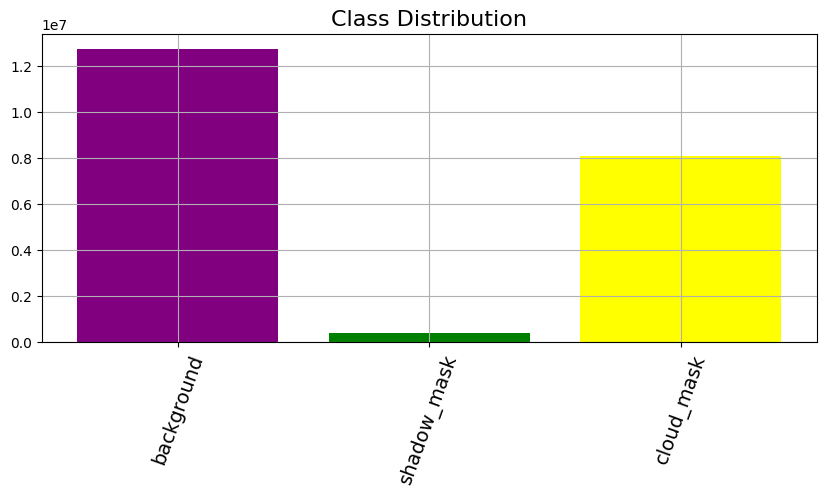

In [8]:
color_map_names = {"background": "purple",
             "shadow_mask": "green",
             "cloud_mask": "yellow"} 

labels = np.array(labels)
class_, count = np.unique(labels, return_counts=True)

inv_map = {value:key for key,value in mask_types.items()}
inv_map[0] = "background"

plt.figure(figsize=(10,4))

for i, cl in enumerate(class_):  
    class_name = inv_map[int(cl)]
    color_name = color_map_names[inv_map[int(cl)]]
    plt.title('Class Distribution', fontsize=16)
    plt.bar(class_name, count[i], color=color_name)
    plt.xticks(rotation=70, fontsize=14)
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import KFold, train_test_split
import pickle

obj_list, obj_list_test = train_test_split(file_list, test_size=0.2, random_state=42)
np.save(f"{out_path}/test_file_list.npy", obj_list_test)

kfold = KFold(n_splits=3, shuffle=True, random_state=1)
for fold, (train_index, val_index) in enumerate(kfold.split(obj_list)):
    print(
        "Objects for training: {}, for validation: {}".format(len(train_index), len(val_index))
    )
    fold_path = "{}/fold_{}_ids.pkl".format(out_path, fold)
    with open(fold_path, "wb") as f:
        pickle.dump(train_index, f, pickle.HIGHEST_PROTOCOL)

In [ ]:
import random
import joblib
import numpy as np
import netCDF4 as nc
import torch
from typing import List, Tuple, Dict, Optional
from torch.utils.data import Dataset, DataLoader


from typing import Tuple
import numpy as np
import random

from sklearn.impute import SimpleImputer

def random_crop(data: np.ndarray, mask: np.ndarray, crop_size: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform a random crop on hyperspectral data and corresponding mask.

    Args:
        data (np.ndarray): Hyperspectral data with shape (H, W, C).
        mask (np.ndarray): Mask corresponding to the data with shape (H, W).
        crop_size (int): The desired crop size (e.g., 448).

    Returns:
        Tuple[np.ndarray, np.ndarray]: Cropped data and mask.
    """
    h, w, _ = data.shape
    ch, cw = crop_size, crop_size

    # Ensure the crop size is smaller than the dimensions of the input
    if h < ch or w < cw:
        raise ValueError("Crop size must be smaller than data dimensions.")

    top = random.randint(0, h - ch)
    left = random.randint(0, w - cw)

    data_cropped = data[top: top + ch, left: left + cw, :]
    mask_cropped = mask[top: top + ch, left: left + cw]
    return data_cropped, mask_cropped

def random_horizontal_flip(data: np.ndarray, mask: np.ndarray, p: float = 0.5) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform a random horizontal flip on hyperspectral data and mask.

    Args:
        data (np.ndarray): Hyperspectral data with shape (H, W, C).
        mask (np.ndarray): Corresponding mask with shape (H, W).
        p (float): Probability of applying the flip. Default is 0.5.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Flipped data and mask.
    """
    if random.random() < p:
        data = np.flip(data, axis=1).copy()  # Flip along the width axis
        mask = np.flip(mask, axis=1).copy()
    return data, mask

def random_vertical_flip(data: np.ndarray, mask: np.ndarray, p: float = 0.5) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform a random vertical flip on hyperspectral data and mask.

    Args:
        data (np.ndarray): Hyperspectral data with shape (H, W, C).
        mask (np.ndarray): Corresponding mask with shape (H, W).
        p (float): Probability of applying the flip. Default is 0.5.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Flipped data and mask.
    """
    if random.random() < p:
        data = np.flip(data, axis=0).copy() # Flip along the height axis
        mask = np.flip(mask, axis=0).copy()
    return data, mask


def random_rotation(data: np.ndarray, mask: np.ndarray, angles: List[int] = [0, 90, 180, 270], p: float = 1.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Perform a random rotation on hyperspectral data and mask.

    Args:
        data (np.ndarray): Hyperspectral data with shape (H, W, C).
        mask (np.ndarray): Corresponding mask with shape (H, W).
        angles (List[int]): List of angles (in degrees) to randomly select from.
        p (float): Probability of applying the rotation. Default is 1.0.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Rotated data and mask.
    """
    if random.random() < p:
        angle = random.choice(angles)
        if angle == 90:
            data = np.rot90(data, k=1, axes=(0, 1)).copy()  # Rotate 90 degrees counterclockwise
            mask = np.rot90(mask, k=1, axes=(0, 1)).copy()
        elif angle == 180:
            data = np.rot90(data, k=2, axes=(0, 1)).copy()  # Rotate 180 degrees
            mask = np.rot90(mask, k=2, axes=(0, 1)).copy()
        elif angle == 270:
            data = np.rot90(data, k=3, axes=(0, 1)).copy()  # Rotate 270 degrees counterclockwise
            mask = np.rot90(mask, k=3, axes=(0, 1)).copy()
    return data, mask

class HyperspectralDataset(Dataset):
    """
    Dataset class for hyperspectral data.
    
    Args:
        base_path (str): Base path for data files.
        model_name (str): Name of the model.
        obj_list (List[str]): List of object file names.
        norm_type (str): Type of normalization to apply.
        class_map (Dict[str, int]): Mapping of class names to integer labels.
        scaler (Optional[object]): Scaler object for normalization.
        apply_transforms (bool): Whether to apply data augmentation transforms. Default is False.
        win_size (int): Window size for data processing. Default is 32.
    """
    def __init__(
        self,
        base_path: str,
        obj_list: List[str],
        norm_type: str,
        class_map: Dict[str, int],
        scaler: Optional[object],
        apply_transforms: bool = False,
        win_size: int = 32,
        test: bool = False,
        cloud_threshold: int = 0.3,
    ):
        self.base_path = base_path
        self.obj_list = obj_list
        self.class_map = class_map
        self.scaler = scaler
        self.norm_type = norm_type
        self.apply_transforms = apply_transforms
        self.win_size = win_size
        self.test = test
        self.cloud_threshold = cloud_threshold

    def __len__(self) -> int:
        """Returns the number of items in the dataset."""
        return len(self.obj_list)


    def __getitem__(self, index: int) -> Tuple[np.ndarray, torch.Tensor]:
        """
        Get a single item from the dataset.
        
        Args:
            index (int): Index of the item to retrieve.
        
        Returns:
            Tuple[np.ndarray, torch.Tensor]: Normalized data and corresponding mask.
        """
        mask_path = self.obj_list[index]
                
        data_path = mask_path
        data = np.load(f"{self.base_path}/images/{data_path}")
        mask_full = np.load(f"{self.base_path}/masks/{mask_path}")          

        if self.apply_transforms:
            pass
            data, mask_full = random_crop(data, mask_full, crop_size=112)
            data, mask_full = random_horizontal_flip(data, mask_full)
            data, mask_full = random_vertical_flip(data, mask_full)
            data, mask_full = random_rotation(data, mask_full)
        elif not self.test:
            data, mask_full = center_crop(data, mask_full, crop_size=224)
        elif self.test:
            pass

        data = self.normalize_data(data)
        return data, mask_full

    def normalize_data(self, data: np.ndarray) -> np.ndarray:
        """
        Normalize the input data based on the specified normalization type.
        
        Args:
            data (np.ndarray): Input data to normalize.
        
        Returns:
            np.ndarray: Normalized data.
        """
        if self.norm_type in ["minmax", "minmax_full"]:
            return (data - self.scaler.data_min_) / (self.scaler.data_max_ - self.scaler.data_min_)
        elif self.norm_type in ["std", "std_full"]:
            return (data - self.scaler.mean_) / (self.scaler.var_**0.5)
        elif self.norm_type == "p_norm":
            lower, higher = compute_percentiles(data, lower=1, higher=99)
            data = np.clip(data, a_min=lower, a_max=higher)
            return (data - self.scaler.mean_) / (self.scaler.var_**0.5)
        else:
            return data  # Return original data if no normalization is specified


def get_dataloader(
    base_path: str,
    norm_type: str,
    mask_types: List[str] = ["dark_surface_mask", "cloud_shadow_mask", "cloud_mask"],
    batch_size: int = 32,
    num_workers: int = 0,
    fold: int = 0,
) -> Tuple[DataLoader, DataLoader, Dict[str, int]]:
    """
    Build and return dataloaders for training and validation.
    
    Args:
        base_path (str): Base path for data files.
        norm_type (str): Type of normalization to apply.
        mask_types (List[str]): Types of masks to use. Default is ["dark_surface_mask", "cloud_shadow_mask", "cloud_mask"].
        model_name (str): Name of the model. Default is "logreg".
        batch_size (int): Batch size for dataloaders. Default is 32.
        num_workers (int): Number of worker processes for data loading. Default is 0.
        fold (int): Fold number for cross-validation. Default is 0.
    
    Returns:
        Tuple[DataLoader, DataLoader, Dict[str, int]]: Train dataloader, validation dataloader, and full class map.
    """
    assert any(x in ["plumes", "cloud_shadow_mask", "cloud_mask", "dark_surface_mask"] for x in mask_types)
    
    obj_list = np.load(base_path + "/file_list.npy")
    scaler = None if norm_type in ["none", "l_norm_clip"] else joblib.load(f"{base_path}/scaler_{norm_type}.pkl")
    fold_ids = joblib.load(f"{base_path}/fold_{fold}_ids.pkl")

    mask = np.ones(len(obj_list), dtype=bool)
    mask[fold_ids] = False  # setting validation indexes as False
    val_list, train_list = obj_list[mask], obj_list[~mask]

    class_map = {type_: i + 1 for i, type_ in enumerate(mask_types)}  # label 0 reserved for normal objects
    
    train_dataset = HyperspectralDataset(
        base_path, train_list, norm_type, class_map, scaler, apply_transforms=True
    )
    train_loader = DataLoader(
        train_dataset, shuffle=True, batch_size=batch_size, num_workers=num_workers
    )
    val_dataset = HyperspectralDataset(
        base_path, val_list, norm_type, class_map, scaler, apply_transforms=False
    )
    val_loader = DataLoader(
        val_dataset, shuffle=False, batch_size=batch_size, num_workers=num_workers
    )

    full_class_map = {**class_map, "background": 0}
    return train_loader, val_loader, full_class_map

In [ ]:
train_loader, val_loader, class_map = get_dataloader(
    out_path,
    "none",
    mask_types = ["cloud_mask"],
    batch_size = 1,
    num_workers = 0,
    fold = 0)

In [ ]:
fig, axs = plt.subplots(2, 4, figsize=(8, 4))  # Changed to 3x9 grid

k = 0
z = 0
for data, mask in train_loader:
    print(data.shape, mask.shape)
    z+=1
    if k >= 4:  # Limit to 9 sets of images
        break
    if z==4:
        continue

    row = k // 2
    col = (k % 2) * 2  # Start index for each set of 3 columns

    B, H, W, C = data.shape  # Get dimensions from current data

    data = data[0]
    mask = mask[0]
    pred = mask

    # Data
    axs[row, col].set_title('Data', fontsize=18)
    axs[row, col].imshow(data[:,:,:])  # Assuming single channel, use appropriate colormap
    axs[row, col].axis('off')

    # Mask and Prediction
    mask_3d = np.zeros((H, W, 3), dtype=np.uint8)
    pred_3d = np.zeros((H, W, 3), dtype=np.uint8)

    for i in range(H):
        for j in range(W):
            mask_3d[i, j] = color_maps_rgb[inv_map[int(mask[i, j])]]
            pred_3d[i, j] = color_maps_rgb[inv_map[int(pred[i, j])]]

    axs[row, col+1].set_title('Mask', fontsize=18)
    axs[row, col+1].imshow(mask_3d)
    axs[row, col+1].axis('off')
    
    #axs[row, col+2].set_title('Prediction', fontsize=18)
    #axs[row, col+2].imshow(pred_3d)
    #axs[row, col+2].axis('off') 
    k+=1


plt.tight_layout()
plt.show()